In [7]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# # # # # # # # # # # 
tag = '2022042420_a05' 

which_train = '01'
which_test = 'train' # 'train'
test_ood = False
samp_size = 2000

use_losses = ['SupCon','Recon']
bs = 16
n_epochs = 5

normed_latent = True
use_cuda = True
empty_cuda = True
cuda_ids = [0,1,2,3]
# n_neighs = 32
# min_dist = 0.1
save_coords = True
# # # # # # # # # # # 

ood = 'ood' if test_ood else ''
which = 'train' if which_test=='train' else 'test'
which = 'ood' if test_ood else which
    
tag_emb = '_'.join([x for x in [tag, f'{samp_size}n', which] if len(x)>0])
print(tag_emb)

2022042420_a05_2000n_train


### Load model.

In [14]:
# %%capture
import torch.nn as nn
import torch
from seqAE_model import SeqAutoencoder
from contra_seq_dataset import ContraSeqDataset
from torch.utils.data import DataLoader, RandomSampler

model = SeqAutoencoder(dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

p = f'/home/kat/Repos/SALSA/results/models/{tag}/{n_epochs-1:02}.pt'
model.load_state_dict(torch.load(p), strict = False)
print(f"Loaded model weights {p}")

if empty_cuda:
    torch.cuda.empty_cache()

if use_cuda:
    if len(cuda_ids) == 1:
        cuda_id = cuda_ids[0]
        device = torch.device(f"cuda:{cuda_id}")
    elif len(cuda_ids) > 1:
        device =  torch.device("cuda")
        print("Let's use", len(cuda_ids), "GPUs!")
        model = nn.DataParallel(model, device_ids=cuda_ids)
        model.to(device)
else:
    device = torch.device("cpu")
    model = model.to(device)

model = model.eval()

Loaded model weights /home/kat/Repos/SALSA/results/models/2022042420_a05/04.pt
Let's use 4 GPUs!


### Dataset to evaluate.

In [16]:
from contra_seq_dataset import ContraSeqDataset, get_dataset_array, get_anc_map
import copy
import random
import numpy as np
random.seed(666)

mdir = '/home/kat/Repos/SALSA/data/model_ready/'

if which_test == 'train':
    anc_path = f'{mdir}{which_train}/train/anchor_smiles.csv'
    aug_path = f'{mdir}{which_train}/train/augmented_smiles.csv'
else:
    if ood:
        tag_caboose = '_ood'
    else:
        tag_caboose = ''
    anc_path = f'{mdir}{which_test}/test/anchor_smiles{tag_caboose}.csv'
    aug_path = f'{mdir}{which_test}/test/augmented_smiles{tag_caboose}.csv'   
print(anc_path)

ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)
_df = copy.deepcopy(ds_arr)

_df.columns = ['Smiles','Atype','Label'] 

if samp_size < len(anc_map):
    rand = random.sample(range(0,len(anc_map)),samp_size)
    rand_idc = np.concatenate([anc_map[x] for x in rand],axis=0)
    df = _df.iloc[rand_idc]
    idc = rand_idc
else:
    df = _df
    idc = range(len(df))

display(df)    

/home/kat/Repos/SALSA/data/model_ready/01/train/anchor_smiles.csv


,Smiles,Atype,Label
14946,NN=c1ccc(N(CCO)CCO)n[nH]1,Anc,14946
74730,Cc1cc(=NN)[nH]nc1N(CCO)CCO,Aug,14946
74731,NN=c1[nH]nc(N(CCO)CCO)cc1S,Aug,14946
74732,NN=c1ccc(N(CCO)C(N)CO)n[nH]1,Aug,14946
74733,COCCN(CCO)c1ccc(=NN)[nH]n1,Aug,14946
...,...,...,...
81565,CC(C)C(=O)Nc1cc(Cl)ccc1C(=O)O,Aug,16313
81566,CCC(=O)N(C)c1cc(Cl)ccc1C(=O)O,Aug,16313
81567,CCCC(=O)Nc1cc(Cl)ccc1C(=O)O,Aug,16313
81568,CCC(=O)Nc1cc(Cl)c(N)cc1C(=O)O,Aug,16313


In [17]:
import numpy as np
from tqdm.notebook import trange, tqdm

# # # # # # 
test_bs = 6
# # # # # # 

loader = DataLoader(ds, batch_size=test_bs, sampler=idc, num_workers=0, pin_memory=True)

latents = []
for samp in tqdm(loader, total=len(df)//test_bs):
    for k,v in samp.items():
        if torch.is_tensor(v):
            samp[k] = v.to(device)
    latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                              samp['avg_mask'], samp['out_mask'], normed_latent)
    latent = latent.cpu().detach().numpy()
    latents.append(latent)
    
latents = np.concatenate(latents, axis=0)
print(latents.shape)

# latents = np.stack(latents,axis=0)
# if test_bs==1:
#     latents = latents.squeeze(1)
# else:
#     latents = np.reshape(latents, (-1,32))
# print(latents.shape)

  0%|          | 0/2000 [00:00<?, ?it/s]

(12000, 32)


### Fit UMAP function.

In [20]:
# # # # # # # # # # # 
n_neighs = 32
min_dist = 0.1
# # # # # # # # # # # 
rdir = '/home/kat/Repos/SALSA/results/'


In [21]:
import umap.umap_ as umap
umapper = umap.UMAP(n_neighbors=n_neighs, min_dist=min_dist, 
                    n_components=2, metric='euclidean')
embedding = umapper.fit_transform(latents)

df['x'] = embedding[:, 0]
df['y'] = embedding[:, 1]

pt = str(min_dist).split('.')[1]
tag_coords = '_'.join([tag_emb, f'{n_neighs}neigh', f'mindist0pt{pt}'])
    
if save_coords:
    csv_out = f'{rdir}umap_dfs/{tag_coords}.csv'
    df.to_csv(csv_out,index=False)
    print(f"Saved smiles and coords to {csv_out}!")

Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022042420_a05_2000n_train_32neigh_mindist0pt1.csv!


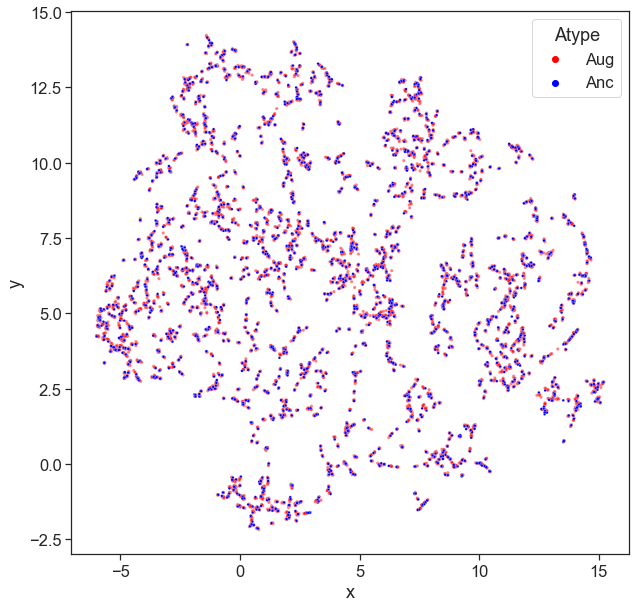

In [22]:
import seaborn as sns 
import matplotlib.pylab as plt

sns.set_theme(style='ticks',font_scale=1.5)

plt.figure(figsize=(10,10))

sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                alpha=0.5, s=10, palette={'Aug':'red'})
sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                alpha=1., s=7, palette={'Anc':'blue'})
png_out = f'{rdir}umap_figs/{tag_coords}.png'
plt.savefig(png_out, bbox_inches='tight')
plt.show()